In [71]:
import cv2
import numpy as np

def segment_image_otsu(image_path):
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img_clear = cv2.imread('img/images-0003.jpg')
    img_clear_rgb =cv2.cvtColor(img_clear, cv2.COLOR_BGR2RGB)

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # otsu
    _, mask = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    # filtro
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    lower_clouds = np.array([0, 0, 235])
    upper_clouds = np.array([180, 60, 255])
    mask_clouds = cv2.inRange(hsv, lower_clouds, upper_clouds)
    
    # kernel
    kernel = np.ones((9,9), np.uint8)
    mask_clouds = cv2.dilate(mask_clouds, kernel, iterations=3)
    mask_clouds = cv2.morphologyEx(mask_clouds, cv2.MORPH_CLOSE, kernel, iterations=2)
    
    # quitar nubes
    mask[mask_clouds == 255] = 0
    mask = img_rgb * (mask[:, :, np.newaxis] == 0)

    # superponer otra imagen
    inverted_mask = 1 - mask_clouds
    fill = img_clear * inverted_mask[:, :, np.newaxis]
    inpainted_image = mask + fill
    
    return img, inpainted_image

In [72]:
import matplotlib.pyplot as plt

def show_segmented_image(original, mask):
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
    plt.title("Imagen Original")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(mask, cmap="gray")
    plt.title("Máscara Segmentada (Otsu)")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

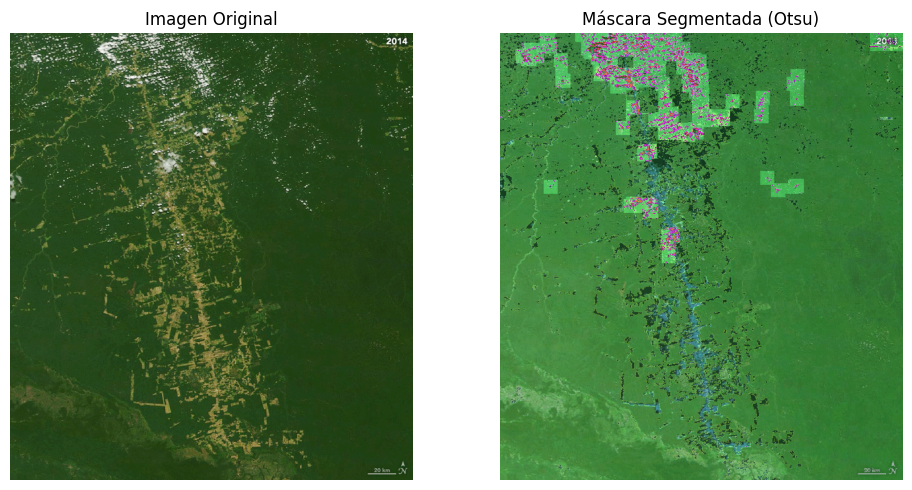

In [73]:
img, mask = segment_image_otsu("img/images-0014.jpg")

show_segmented_image(img, mask)


In [74]:
def refine_segmentation(mask):
    kernel = np.ones((3,3), np.uint8)
    
    refined_mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=2)

    _, binary_mask = cv2.threshold(refined_mask, 0, 127, cv2.THRESH_BINARY)
    
    return binary_mask


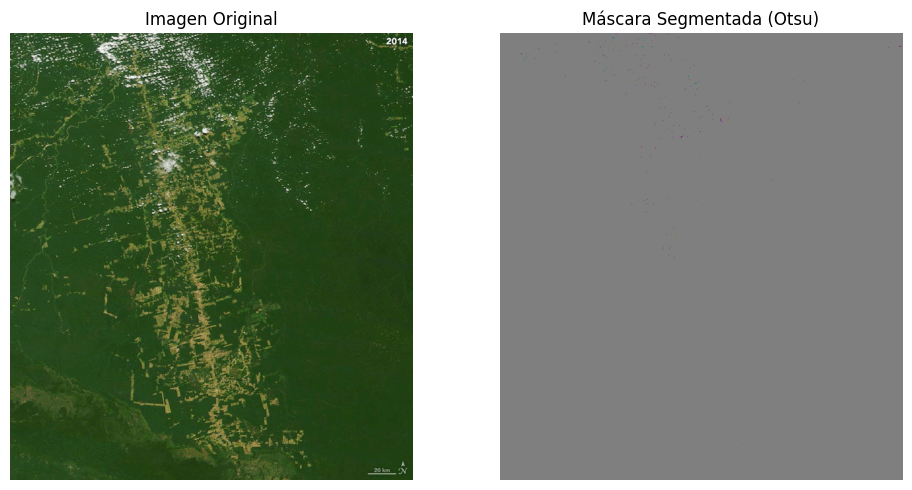

In [75]:
binary_mask = refine_segmentation(mask)
show_segmented_image(img, binary_mask)  
